In [1]:
import pandas as pd

small_file = r"D:\CSE-CICIDS2018\Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv"
df_check = pd.read_csv(small_file, nrows=5)
df_check.columns = df_check.columns.str.strip()
print(f"Total columns: {len(df_check.columns)}")
print(df_check.columns.tolist())

# Check label column
print(f"\nLabel sample:")
df_label = pd.read_csv(small_file, nrows=200)
df_label.columns = df_label.columns.str.strip()
label_col = [c for c in df_label.columns if 'label' in c.lower()]
print(f"Label column name: {label_col}")
if label_col:
    print(df_label[label_col[0]].value_counts())

Total columns: 80
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk 

In [2]:
import pandas as pd

attack_file = r"D:\CSE-CICIDS2018\Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv"
df_labels = pd.read_csv(attack_file, usecols=lambda c: c.strip() == 'Label', low_memory=False)
df_labels.columns = df_labels.columns.str.strip()
print(df_labels['Label'].value_counts())

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


In [3]:
import pandas as pd
import os

path = r"D:\CSE-CICIDS2018"

for f in sorted(os.listdir(path)):
    fpath = os.path.join(path, f)
    df = pd.read_csv(fpath, usecols=lambda c: c.strip() == 'Label', low_memory=False)
    df.columns = df.columns.str.strip()
    print(f"\n{f}")
    print(df['Label'].value_counts())


Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign    762384
Bot       286191
Name: count, dtype: int64

Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Label                            1
Name: count, dtype: int64

Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign              1048009
Brute Force -Web        362
Brute Force -XSS        151
SQL Injection            53
Name: count, dtype: int64

Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                    7372557
DDoS attacks-LOIC-HTTP     576191
Name: count, dtype: int64

Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign           238037
Infilteration     93063
Label                25
Name: count, dtype: int64

Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                   996077
DoS attacks-GoldenEye     41508
DoS attacks-Slowloris     10990
Name: count,

Cell 1 — Imports and Paths

In [4]:
import os, pickle, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

DATA_PATH   = r"D:\CSE-CICIDS2018"
ARTIFACT_PATH   = r"..\artifacts"
CHECKPOINT_PATH = r"..\checkpoints"

os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

FILES = [
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
]

print(f"Files: {len(FILES)}")
print("Imports OK")

Files: 10
Imports OK


Cell 2 — Feature List (CIC-IDS2018 column names)

In [5]:
FEATURES = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Fwd Pkt Len Max',
    'Fwd Pkt Len Min',
    'Fwd Pkt Len Mean',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Min',
    'Bwd Pkt Len Mean',
    'Flow Byts/s',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd PSH Flags',
    'FIN Flag Cnt',
    'SYN Flag Cnt',
    'RST Flag Cnt',
    'PSH Flag Cnt',
    'ACK Flag Cnt',
    'Down/Up Ratio',
    'Fwd Seg Size Avg',
    'Bwd Seg Size Avg',
]

print(f"Feature count: {len(FEATURES)}")
print("Feature list locked.")

Feature count: 25
Feature list locked.


Cell 3 — Load and Clean (With Checkpoint + Tuesday chunking)

In [6]:
CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, 'df_clean.pkl')

TUESDAY_FILE = "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv"

if os.path.exists(CHECKPOINT_FILE):
    print("Checkpoint found — loading df_clean")
    df = pd.read_pickle(CHECKPOINT_FILE)
    print(f"Loaded shape: {df.shape}")

else:
    frames = []

    for fname in FILES:
        fpath = os.path.join(DATA_PATH, fname)
        print(f"\nLoading {fname}...")

        # Tuesday is 3.9GB — load in chunks
        if fname == TUESDAY_FILE:
            print("  Large file — using chunked loading...")
            chunks = []
            for chunk in pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False,
                chunksize=500000
            ):
                chunk.columns = chunk.columns.str.strip()
                # Drop junk header rows immediately
                chunk = chunk[chunk['Label'] != 'Label']
                for col in chunk.select_dtypes(include='float64').columns:
                    chunk[col] = chunk[col].astype('float32')
                chunks.append(chunk)
            file_df = pd.concat(chunks, ignore_index=True)
            del chunks; gc.collect()

        else:
            file_df = pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False
            )
            file_df.columns = file_df.columns.str.strip()
            # Drop junk header rows
            file_df = file_df[file_df['Label'] != 'Label']
            for col in file_df.select_dtypes(include='float64').columns:
                file_df[col] = file_df[col].astype('float32')

        print(f"  Shape: {file_df.shape} | Labels: {file_df['Label'].unique()}")
        frames.append(file_df)
        del file_df; gc.collect()

    print("\nConcatenating all files...")
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f"Combined shape: {df.shape}")

    # Replace inf
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop NaN
    before = len(df)
    df.dropna(inplace=True)
    print(f"Dropped NaN: {before - len(df)}")

    # Drop duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Dropped duplicates: {before - len(df)}")

    df.to_pickle(CHECKPOINT_FILE)
    print(f"\nCheckpoint saved. Final shape: {df.shape}")

Checkpoint found — loading df_clean
Loaded shape: (9777285, 26)


Cell 4 — Label Distribution

In [7]:
print("=== LABEL DISTRIBUTION ===\n")
counts = df['Label'].value_counts()
print(counts)
print(f"\nTotal rows: {len(df):,}")
benign = counts.get('Benign', 0)
attack = len(df) - benign
print(f"\nBenign: {benign:,} ({benign/len(df)*100:.1f}%)")
print(f"Attack: {attack:,} ({attack/len(df)*100:.1f}%)")

=== LABEL DISTRIBUTION ===

Label
Benign                      8487399
DDoS attacks-LOIC-HTTP       575256
DDOS attack-HOIC             198830
Bot                          143395
DoS attacks-Hulk             122294
Infilteration                102858
SSH-Bruteforce                93988
DoS attacks-GoldenEye         41356
DoS attacks-Slowloris          9239
DDOS attack-LOIC-UDP           1730
Brute Force -Web                527
Brute Force -XSS                225
SQL Injection                    80
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64

Total rows: 9,777,285

Benign: 8,487,399 (86.8%)
Attack: 1,289,886 (13.2%)



Cell 5 — Encode + Split + Scale

In [8]:
CHECKPOINT_SPLIT = os.path.join(CHECKPOINT_PATH, 'split.pkl')

if os.path.exists(CHECKPOINT_SPLIT):
    print("Checkpoint found — loading split")
    with open(CHECKPOINT_SPLIT, 'rb') as f:
        X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)
    print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")

else:
    df = df[df['Label'] != 'Label']
    df['Label_bin'] = (df['Label'] != 'Benign').astype(int)

    print(f"Benign: {(df['Label_bin']==0).sum():,} | Attack: {(df['Label_bin']==1).sum():,}")

    X = df[FEATURES].values.astype('float32')
    y = df['Label_bin'].values
    del df; gc.collect()

    # Nuclear inf/nan clean on the numpy array
    print(f"Inf count before clean: {np.isinf(X).sum()}")
    print(f"NaN count before clean: {np.isnan(X).sum()}")
    X = np.where(np.isinf(X), np.nan, X)
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    print(f"Inf count after clean: {np.isinf(X).sum()}")
    print(f"NaN count after clean: {np.isnan(X).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
    del X; gc.collect()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    del X_train; gc.collect()

    with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print("scaler.pkl saved")

    with open(CHECKPOINT_SPLIT, 'wb') as f:
        pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test), f)
    print("Split checkpoint saved")

Checkpoint found — loading split
X_train: (7821828, 25) | X_test: (1955457, 25)


Cell 6 — Train XGBoost

In [9]:
# Retrain with explicit base_score to fix SHAP compatibility
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

import time
t0 = time.time()

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    min_child_weight=5,
    base_score=0.5,          # ← explicit fix
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_scaled, y_train)
print(f"Done in {time.time()-t0:.1f}s")

# Save immediately
with open(os.path.join(ARTIFACT_PATH, 'model.pkl'), 'wb') as f:
    pickle.dump(model, f)
print("model.pkl saved")

# Now try SHAP
explainer = shap.TreeExplainer(model)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'wb') as f:
    pickle.dump(explainer, f)
print("explainer.pkl saved")

Done in 230.0s
model.pkl saved
explainer.pkl saved


Cell 7 — Evaluate

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99   1697480
      Attack       0.92      0.93      0.93    257977

    accuracy                           0.98   1955457
   macro avg       0.96      0.96      0.96   1955457
weighted avg       0.98      0.98      0.98   1955457

FN rate: 7.26%
FP rate: 1.15%


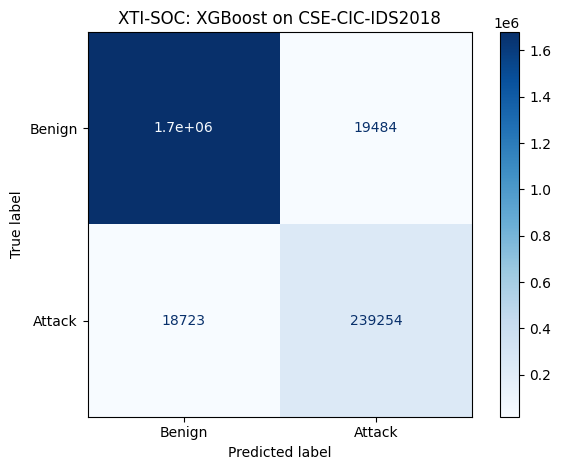

In [10]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test_scaled)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

print(f"FN rate: {((y_test==1)&(y_pred==0)).sum()/(y_test==1).sum()*100:.2f}%")
print(f"FP rate: {((y_test==0)&(y_pred==1)).sum()/(y_test==0).sum()*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues')
plt.title('XTI-SOC: XGBoost on CSE-CIC-IDS2018')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

Cell 8 — Save Remaining Artifacts

In [11]:
# Feature list
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'wb') as f:
    pickle.dump(FEATURES, f)
print(f"feature_list.pkl saved — {len(FEATURES)} features")

# SHAP explainer
print("Building SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'wb') as f:
    pickle.dump(explainer, f)
print("explainer.pkl saved")

feature_list.pkl saved — 25 features
Building SHAP TreeExplainer...
explainer.pkl saved


Cell 9 — Verify All Artifacts

In [13]:
import numpy as np

print("=== ARTIFACT VERIFICATION ===\n")
for a in ['model.pkl', 'scaler.pkl', 'explainer.pkl', 'feature_list.pkl']:
    path = os.path.join(ARTIFACT_PATH, a)
    size = os.path.getsize(path) / 1024**2
    print(f"✓ {a:25s} {size:.1f} MB")

# Reload from disk
with open(os.path.join(ARTIFACT_PATH, 'model.pkl'), 'rb') as f:
    m = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'rb') as f:
    sc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'rb') as f:
    ex = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'rb') as f:
    fl = pickle.load(f)

# Smoke test predict_proba
dummy = np.zeros((1, len(fl)), dtype='float32')
dummy_scaled = sc.transform(dummy)
proba = m.predict_proba(dummy_scaled)
print(f"\nSmoke test predict_proba: {proba}")

# SHAP smoke test — XGBoost safe
sv = ex.shap_values(X_test_scaled[:50])
print(f"SHAP output type: {type(sv)}")
print(f"SHAP shape: {sv.shape if hasattr(sv, 'shape') else [s.shape for s in sv]}")

if isinstance(sv, list):
    shap_array = sv[1]
else:
    shap_array = sv

assert shap_array.shape == (50, len(fl)), f"Shape mismatch: {shap_array.shape}"
print(f"SHAP smoke test passed — shape: {shap_array.shape}")

print("\n=== PHASE 0 COMPLETE ===")
print("All 4 artifacts verified. Ready for Phase 1.")

=== ARTIFACT VERIFICATION ===

✓ model.pkl                 3.3 MB
✓ scaler.pkl                0.0 MB
✓ explainer.pkl             12.3 MB
✓ feature_list.pkl          0.0 MB

Smoke test predict_proba: [[0.75147927 0.24852075]]
SHAP output type: <class 'numpy.ndarray'>
SHAP shape: (50, 25)
SHAP smoke test passed — shape: (50, 25)

=== PHASE 0 COMPLETE ===
All 4 artifacts verified. Ready for Phase 1.


In [15]:
print("=== SCALED FEATURE STATS (sample) ===")
import pandas as pd
stats = pd.DataFrame(X_train_scaled[:10000], columns=FEATURES).describe().round(3)
print(stats.loc[['mean', 'std', 'min', 'max']].to_string())

=== SCALED FEATURE STATS (sample) ===
      Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  Fwd Pkt Len Mean  Bwd Pkt Len Max  Bwd Pkt Len Min  Bwd Pkt Len Mean  Flow Byts/s  Flow Pkts/s  Flow IAT Mean  Fwd IAT Mean  Bwd IAT Mean  Fwd PSH Flags  FIN Flag Cnt  SYN Flag Cnt  RST Flag Cnt  PSH Flag Cnt  ACK Flag Cnt  Down/Up Ratio  Fwd Seg Size Avg  Bwd Seg Size Avg
mean          0.001        -0.008        -0.002            0.004           -0.003            0.018           -0.003             0.014            0.007           -0.004             0.002       -0.003        0.002         -0.001        -0.000         0.013          0.006        -0.002         0.006         0.005        -0.007         0.003         -0.002             0.014             0.002
std           0.054         0.757         1.029            1.188            1.037            1.629            0.882             1.325            1.004            0.990             

In [16]:
import pandas as pd
import numpy as np

frames = []
for fname in FILES:
    fpath = os.path.join(DATA_PATH, fname)
    chunk = pd.read_csv(fpath, usecols=lambda c: c.strip() == 'Label', low_memory=False)
    chunk.columns = chunk.columns.str.strip()
    chunk = chunk[chunk['Label'] != 'Label']
    frames.append(chunk)

all_labels = pd.concat(frames, ignore_index=True)
df_clean = pd.read_pickle(os.path.join(CHECKPOINT_PATH, 'df_clean.pkl'))
all_labels_clean = all_labels.loc[df_clean.index].reset_index(drop=True)
del all_labels, df_clean; gc.collect()

all_labels_bin = (all_labels_clean['Label'] != 'Benign').astype(int)

from sklearn.model_selection import train_test_split
_, test_idx = train_test_split(
    np.arange(len(all_labels_bin)),
    test_size=0.2,
    stratify=all_labels_bin,
    random_state=42
)

test_labels = all_labels_clean['Label'].iloc[test_idx].reset_index(drop=True)

missed_mask = (y_test == 1) & (y_pred == 0)
print("=== MISSED ATTACKS BY TYPE ===")
print(test_labels[missed_mask].value_counts())
print(f"\nTotal missed: {missed_mask.sum():,}")

=== MISSED ATTACKS BY TYPE ===
Label
Infilteration             17275
DDoS attacks-LOIC-HTTP     1217
DoS attacks-GoldenEye       106
DoS attacks-Slowloris        40
Brute Force -Web             29
Bot                          26
Brute Force -XSS             13
DoS attacks-Hulk              9
SSH-Bruteforce                4
SQL Injection                 4
Name: count, dtype: int64

Total missed: 18,723


In [17]:
# What's the total Infiltration count in test set?
print("=== INFILTRATION BREAKDOWN ===")
inf_total = (test_labels == 'Infilteration').sum()
inf_missed = 17275
print(f"Total Infiltration in test: {inf_total:,}")
print(f"Missed: {inf_missed:,}")
print(f"Miss rate: {inf_missed/inf_total*100:.1f}%")

=== INFILTRATION BREAKDOWN ===
Total Infiltration in test: 20,547
Missed: 17,275
Miss rate: 84.1%
